In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [16]:
df=pd.read_csv('stud.csv')

In [17]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### check null values


In [18]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

no null values

### check duplicates

In [19]:
df.duplicated().sum()

np.int64(0)

no duplicates

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [21]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [22]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [23]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
print("categories in [gender] variable:")
print(df['gender'].unique())
print("categories in [race_ethnicity] variable:")
print(df["race_ethnicity"].unique())
print("categories in [parental_level_of_education] variable:")
print(df["parental_level_of_education"].unique())
print("categories in [lunch] variable:")
print(df["lunch"].unique())
print("df['test_preparation_course'] variable:")
print(df['test_preparation_course'].unique())

categories in [gender] variable:
['female' 'male']
categories in [race_ethnicity] variable:
['group B' 'group C' 'group A' 'group D' 'group E']
categories in [parental_level_of_education] variable:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in [lunch] variable:
['standard' 'free/reduced']
df['test_preparation_course'] variable:
['none' 'completed']


In [25]:
## define numerical and categorical features
num_features=[features for features in df.columns if df[features].dtype!='O']
cat_features=[features for features in df.columns if df[features].dtype=='O']
print('we have {} numerical features : {}'.format(len(num_features), num_features))
print('we have {} categorical features : {}'.format(len(cat_features), cat_features))

we have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
we have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### adding columns for total score and average score

In [26]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average_score']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
reading_full=df[df['reading_score']==100]['average_score'].count()
writing_full=df[df['writing_score']==100]['average_score'].count()
math_full=df[df['math_score']==100]['average_score'].count()

print("number of students with full marks in reading :",reading_full)
print("number of students with full marks in writing :",writing_full)
print("number of students with full marks in math :",math_full)

number of students with full marks in reading : 17
number of students with full marks in writing : 14
number of students with full marks in math : 7


In [28]:
reading_less_20=df[df['reading_score']<20]['average_score'].count()
writing_less_20=df[df['writing_score']<20]['average_score'].count()
math_less_20=df[df['math_score']<20]['average_score'].count()
print("number of students with less than 20 marks in reading :",reading_less_20)
print("number of students with less than 20 marks in writing :",writing_less_20)
print("number of students with less than 20 marks in math :",math_less_20)


number of students with less than 20 marks in reading : 1
number of students with less than 20 marks in writing : 3
number of students with less than 20 marks in math : 4


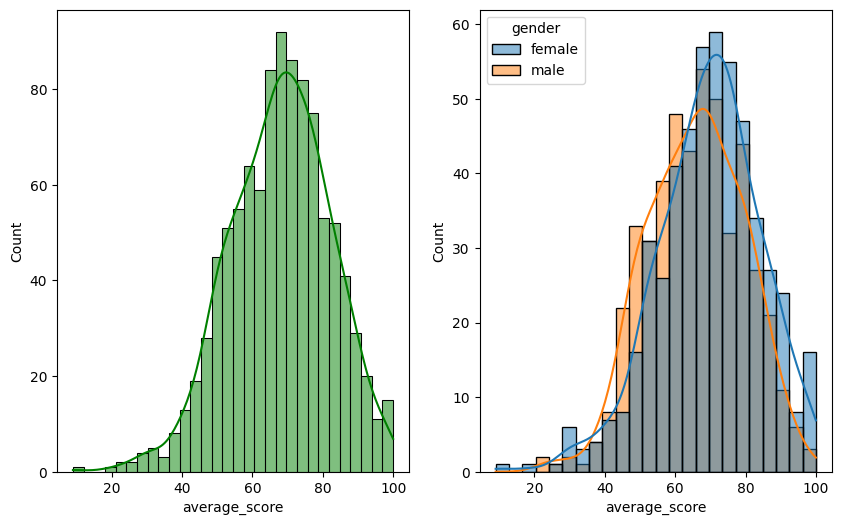

In [29]:
## histogram of average score
fig, ax=plt.subplots(1,2,figsize=(10,6))
plt.subplot(121)
sns.histplot(df['average_score'], kde=True, bins=30,color='g')
plt.subplot(122)
sns.histplot(data=df, x='average_score', kde=True, hue='gender')
plt.show() 

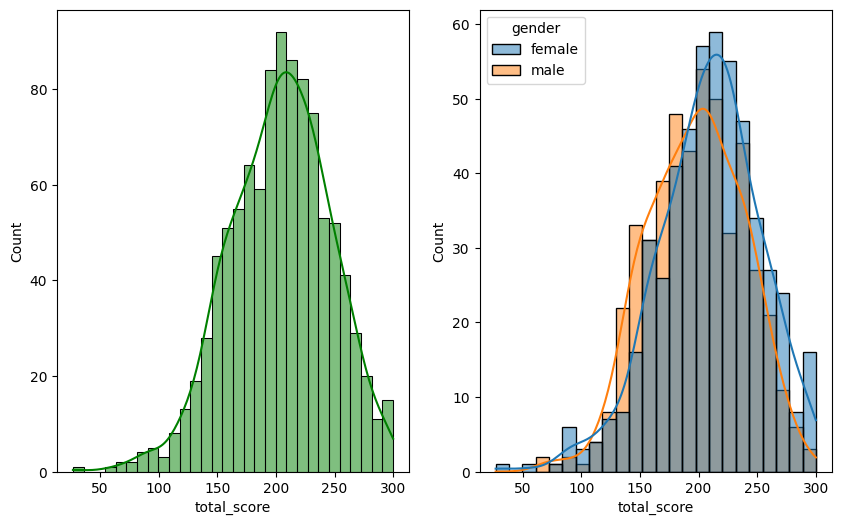

In [30]:
## histogram of total score
fig, ax=plt.subplots(1,2,figsize=(10,6))
plt.subplot(121)
sns.histplot(df['total_score'], kde=True, bins=30,color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')
plt.show() 

### insights

#### females tends to perform well than males
